In [8]:
import numpy as np
import matplotlib.pyplot as plt
from functions import *
from states import *
import os
import math
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

In [ ]:
result_dir = "bootstrap_data" # directory where the bootstrap results will be saved

In [ ]:
# Set the parameters, similar to the parameters used in the previous scripts.

n = 5
p = 0.3
depth = 5
param_tag = f"p{str(p).replace('.', 'd')}"

rho = noisy_ghz_state(n, p)
K_list = [2,3,4,5]

true_values = {K: state_moment(rho, K) for K in K_list}
method = "coincide"

In [14]:

q_list = [0,1,2,3,4,5] # number of qubits compressed n -> q (q=0 means fully coherent algo, q=n means fully local algo)
plot_mode = "NU1_vary_NM" # plot_mode can be either "NU1_vary_NM" (varying N_M with fixed N_U=1) or "NM100_vary_NU" (varying N_U with fixed N_M=100)
x_axis_mode = "copy" # By default it is "copy". It can be either "circuit" (x-axis is the number of circuits) or "copy" (x-axis is the number of copies). Note that the number of copies is equal to the number of circuits multiplied by the number of measurements per circuit.


rescale_std = 1/3 # rescale the standard deviation by a factor of 1/3 to make the error bar smaller and more visible. This is just for visualization purpose and does not affect the actual data.

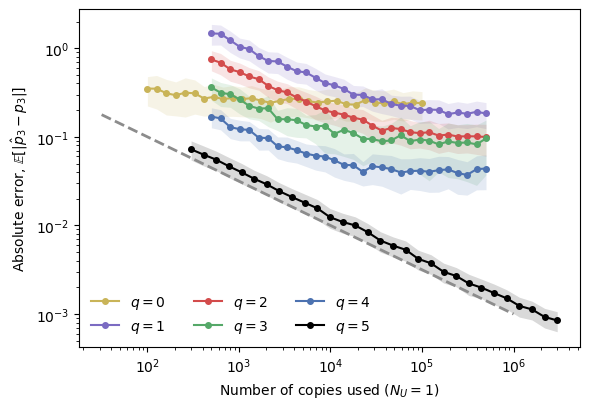

In [15]:
K_plot = 3  # the state power to be plotted. For example, K_plot = 5 means the plot shows the estimation error of tr(rho^5). It must be within the K_list.

plt.figure(figsize=(6.0, 4.2))

q_color_map = {
    0: "#c9b458",  # yellow/gold
    1: "#7b6bc2",  # purple
    2: "#d34b4b",  # red
    3: "#55a868",  # green
    4: "#4c72b0",  # blue
    5: "#000000",  # black
}

q_marker_map = {q: "o" for q in q_list}
q_linestyle_map = {q: "-" for q in q_list}


for q in q_list:
    if q == n:
        curve_path = os.path.join(result_dir, f"bootstrap_curve_noisy_ghz_n{n}_{param_tag}_depth{depth}_q{q}.npz")
    else:
        curve_path = os.path.join(result_dir, f"bootstrap_curve_noisy_ghz_n{n}_{param_tag}_depth{depth}_q{q}_{plot_mode}.npz")

    if not os.path.exists(curve_path):
        print("Missing curve file:", curve_path)
        continue

    curve = np.load(curve_path)

    N_raw = curve["N_values"]

    if x_axis_mode == "raw":
        x_values = N_raw
        xlabel = r"Raw bootstrap sample size, $N$"
    elif x_axis_mode == "circuit":
        if q == 0:
            x_values = N_raw
        elif q == n:
            x_values = N_raw
        else:
            x_values = (K_plot - 1) * N_raw
        xlabel = r"Number of circuit executions"
    elif x_axis_mode == "copy":
        if q == 0:
            x_values = N_raw
        elif q == n:
            x_values = K_plot * N_raw
        else:
            x_values = sum(range(2, K_plot + 1)) * N_raw
        xlabel = r"Number of copies used"
    else:
        raise ValueError("x_axis_mode must be 'raw', 'circuit', or 'copy'.")

    mean_error = curve[f"mean_error_K{K_plot}"]
    std_error = curve[f"std_error_K{K_plot}"]

    color = q_color_map[q]
    marker = q_marker_map.get(q, "o")
    linestyle = q_linestyle_map.get(q, "-")

    lower = np.maximum(mean_error - std_error * rescale_std, 1e-16)
    upper = mean_error + std_error * rescale_std

    plt.plot(x_values, mean_error, color=color, linestyle=linestyle, marker=marker, markersize=4, linewidth=1.5, label=rf"$q={q}$")
    plt.fill_between(x_values, lower, upper, color=color, alpha=0.15, linewidth=0)

    curve.close()

x_ref = np.logspace(1.5, 6, 200)
y_ref = 1 / np.sqrt(x_ref)

plt.plot(x_ref, y_ref, "--", linewidth=2, color="0.55")

# plt.xlim((10**3, 10**6))
# plt.ylim((10**-3, 10**0.5))

plt.xscale("log")
plt.yscale("log")
plt.ylabel(rf"Absolute error, $\mathbb{{E}}[|\hat{{p}}_{K_plot}-p_{K_plot}|]$")

if plot_mode == "NM100_vary_NU":
    xlabel = xlabel + r" $(N_M=100)$"
elif plot_mode == "NU1_vary_NM":
    xlabel = xlabel + r" $(N_U=1)$"

plt.xlabel(xlabel)
plt.legend(ncol=3, frameon=False)
plt.tight_layout()